In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def read_sdds_file(filename):
    """Read an OPAL/OPALX SDDS-format .stat/.dat file into a DataFrame."""
    col_names = []
    col_info = {}
    header_lines = 0
    first_data_line = None

    with open(filename, "r") as f:
        for line in f:
            header_lines += 1
            stripped = line.strip()

            if stripped.startswith("&column"):
                col_def = stripped
                while "&end" not in col_def:
                    next_line = next(f).strip()
                    header_lines += 1
                    col_def += " " + next_line

                name_match = re.search(r"name\s*=\s*(\S+)", col_def)
                type_match = re.search(r"type\s*=\s*(\S+)", col_def)
                unit_match = re.search(r"units\s*=\s*(\S+)", col_def)
                desc_match = re.search(r'description\s*=\s*"([^"]*)"', col_def)

                name = name_match.group(1).strip(",\"") if name_match else f"col_{len(col_names)}"
                dtype = type_match.group(1).strip(",\"") if type_match else "double"
                unit = unit_match.group(1).strip(",\"") if unit_match else ""
                desc = desc_match.group(1) if desc_match else ""

                col_names.append(name)
                col_info[name] = (dtype, unit, desc)

            if stripped.startswith("&data"):
                while True:
                    next_line = next(f).strip()
                    header_lines += 1
                    parts = next_line.split()
                    if len(parts) >= 2:
                        try:
                            float(parts[0])
                            float(parts[1])
                            first_data_line = next_line
                            break
                        except ValueError:
                            pass
                    if len(parts) == 1:
                        try:
                            float(parts[0])
                            if "." not in parts[0] and "e" not in parts[0].lower():
                                continue
                            first_data_line = next_line
                            break
                        except ValueError:
                            continue
                break

    if first_data_line is None:
        raise RuntimeError(f"Could not find numeric data in SDDS file: {filename}")

    data_rows = [([float(x) for x in first_data_line.split()])]

    with open(filename, "r") as f:
        for _ in range(header_lines):
            next(f)
        for line in f:
            stripped = line.strip()
            if stripped and not stripped.startswith("&"):
                try:
                    values = [float(x) for x in stripped.split()]
                    if len(values) == len(col_names):
                        data_rows.append(values)
                except ValueError:
                    continue

    df = pd.DataFrame(data_rows, columns=col_names)
    return df, col_info


def stat_columns(path):
    """Return available SDDS column names, units, and descriptions."""
    _, col_info = read_sdds_file(path)
    return pd.DataFrame(
        [
            {"column": name, "unit": unit, "description": desc}
            for name, (_, unit, desc) in col_info.items()
        ]
    )


def _find_time_column(df):
    for cand in ["s", "t", "time", "Time", "z", "step"]:
        if cand in df.columns:
            return cand
    for c in df.columns:
        if pd.api.types.is_numeric_dtype(df[c]):
            return c
    raise RuntimeError("No numeric time-like column found")


def compare_stats(*paths, columns, x_col=None, data_range=None, save_as="comparison.svg", ncols=2):
    """Compare .stat files using one subplot for each requested column.

    Parameters
    ----------
    paths : str
        One or more .stat files to compare.
    columns : sequence of str
        Column names to plot. Each column gets its own subplot.
    x_col : str, optional
        Column for the shared x-axis. Defaults to 's' when present, otherwise
        the first numeric time-like column.
    data_range : sequence of two ints, optional
        Datapoint range [start, stop] to plot, excluding stop. Defaults to all rows.
    save_as : str or None
        Output image path. Set to None to skip saving.
    ncols : int
        Number of subplot columns in the figure grid.
    """
    if not paths:
        raise ValueError("Provide at least one .stat file")

    if isinstance(columns, str):
        columns = [columns]
    columns = list(columns)
    if not columns:
        raise ValueError("Provide at least one column name to plot")

    if data_range is None:
        row_slice = slice(None)
    else:
        try:
            start, stop = data_range
        except (TypeError, ValueError) as exc:
            raise ValueError("data_range must be [start, stop]") from exc
        row_slice = slice(start, stop)

    loaded = [read_sdds_file(p) for p in paths]
    dfs = [item[0] for item in loaded]
    col_infos = [item[1] for item in loaded]
    labels = [os.path.basename(p) for p in paths]
    n = len(dfs)

    if x_col is None:
        x_col = "s" if "s" in dfs[0].columns else _find_time_column(dfs[0])

    missing_x = [label for df, label in zip(dfs, labels) if x_col not in df.columns]
    if missing_x:
        raise ValueError(f"x_col '{x_col}' is missing from: {', '.join(missing_x)}")

    missing_columns = [col for col in columns if not any(col in df.columns for df in dfs)]
    if missing_columns:
        available = ", ".join(dfs[0].columns)
        raise ValueError(
            "Requested columns not found in any file: "
            f"{', '.join(missing_columns)}\\n"
            f"Available columns in {labels[0]}: {available}"
        )

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 8,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.dpi": 150,
        "savefig.dpi": 200,
        "axes.grid": True,
        "grid.alpha": 0.35,
        "grid.linestyle": "--",
    })

    ncols = max(1, min(int(ncols), len(columns)))
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 2.5 * nrows),
        sharex=True,
        constrained_layout=True,
        squeeze=False,
    )

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    diff_color = "silver"

    def _column_label(col):
        for col_info in col_infos:
            if col in col_info:
                _, unit, _ = col_info[col]
                return f"{col} [{unit}]" if unit else col
        return col

    def _plot_panel(ax, col):
        for i, (df, label) in enumerate(zip(dfs, labels)):
            if col not in df.columns:
                continue
            view = df.iloc[row_slice]
            ax.plot(view[x_col], view[col], color=colors[i % len(colors)], lw=1.8, label=label)

        ax.set_title(col)
        ax.set_ylabel(_column_label(col))
        ax.legend(loc="best", framealpha=0.7)

        if n == 2 and col in dfs[0].columns and col in dfs[1].columns:
            df1, df2 = dfs[0].iloc[row_slice], dfs[1].iloc[row_slice]
            y1, y2 = df1[col].values, df2[col].values
            x1 = df1[x_col].values
            minp = min(len(y1), len(y2), len(x1))
            err = np.abs(y1[:minp] - y2[:minp])
            ax2 = ax.twinx()
            ax2.plot(x1[:minp], err, color=diff_color, lw=1.2, ls="--", alpha=0.7, label="|Delta|")
            ax2.set_ylabel("|Delta|", color=diff_color, fontsize=9)
            ax2.tick_params(axis="y", colors=diff_color, labelsize=8)
            ax2.yaxis.get_offset_text().set_color(diff_color)
            if (err > 0).any():
                ax2.set_yscale("log")

    flat_axes = axes.ravel()
    for ax, col in zip(flat_axes, columns):
        _plot_panel(ax, col)

    for ax in flat_axes[len(columns):]:
        ax.set_visible(False)

    for ax in axes[-1, :]:
        if ax.get_visible():
            ax.set_xlabel(x_col)

    if save_as is not None:
        plt.savefig(save_as)
    plt.show()


# Backwards-compatible alias. The columns argument is still required.
def compare_two_stats(path1, path2, **kwargs):
    compare_stats(path1, path2, **kwargs)


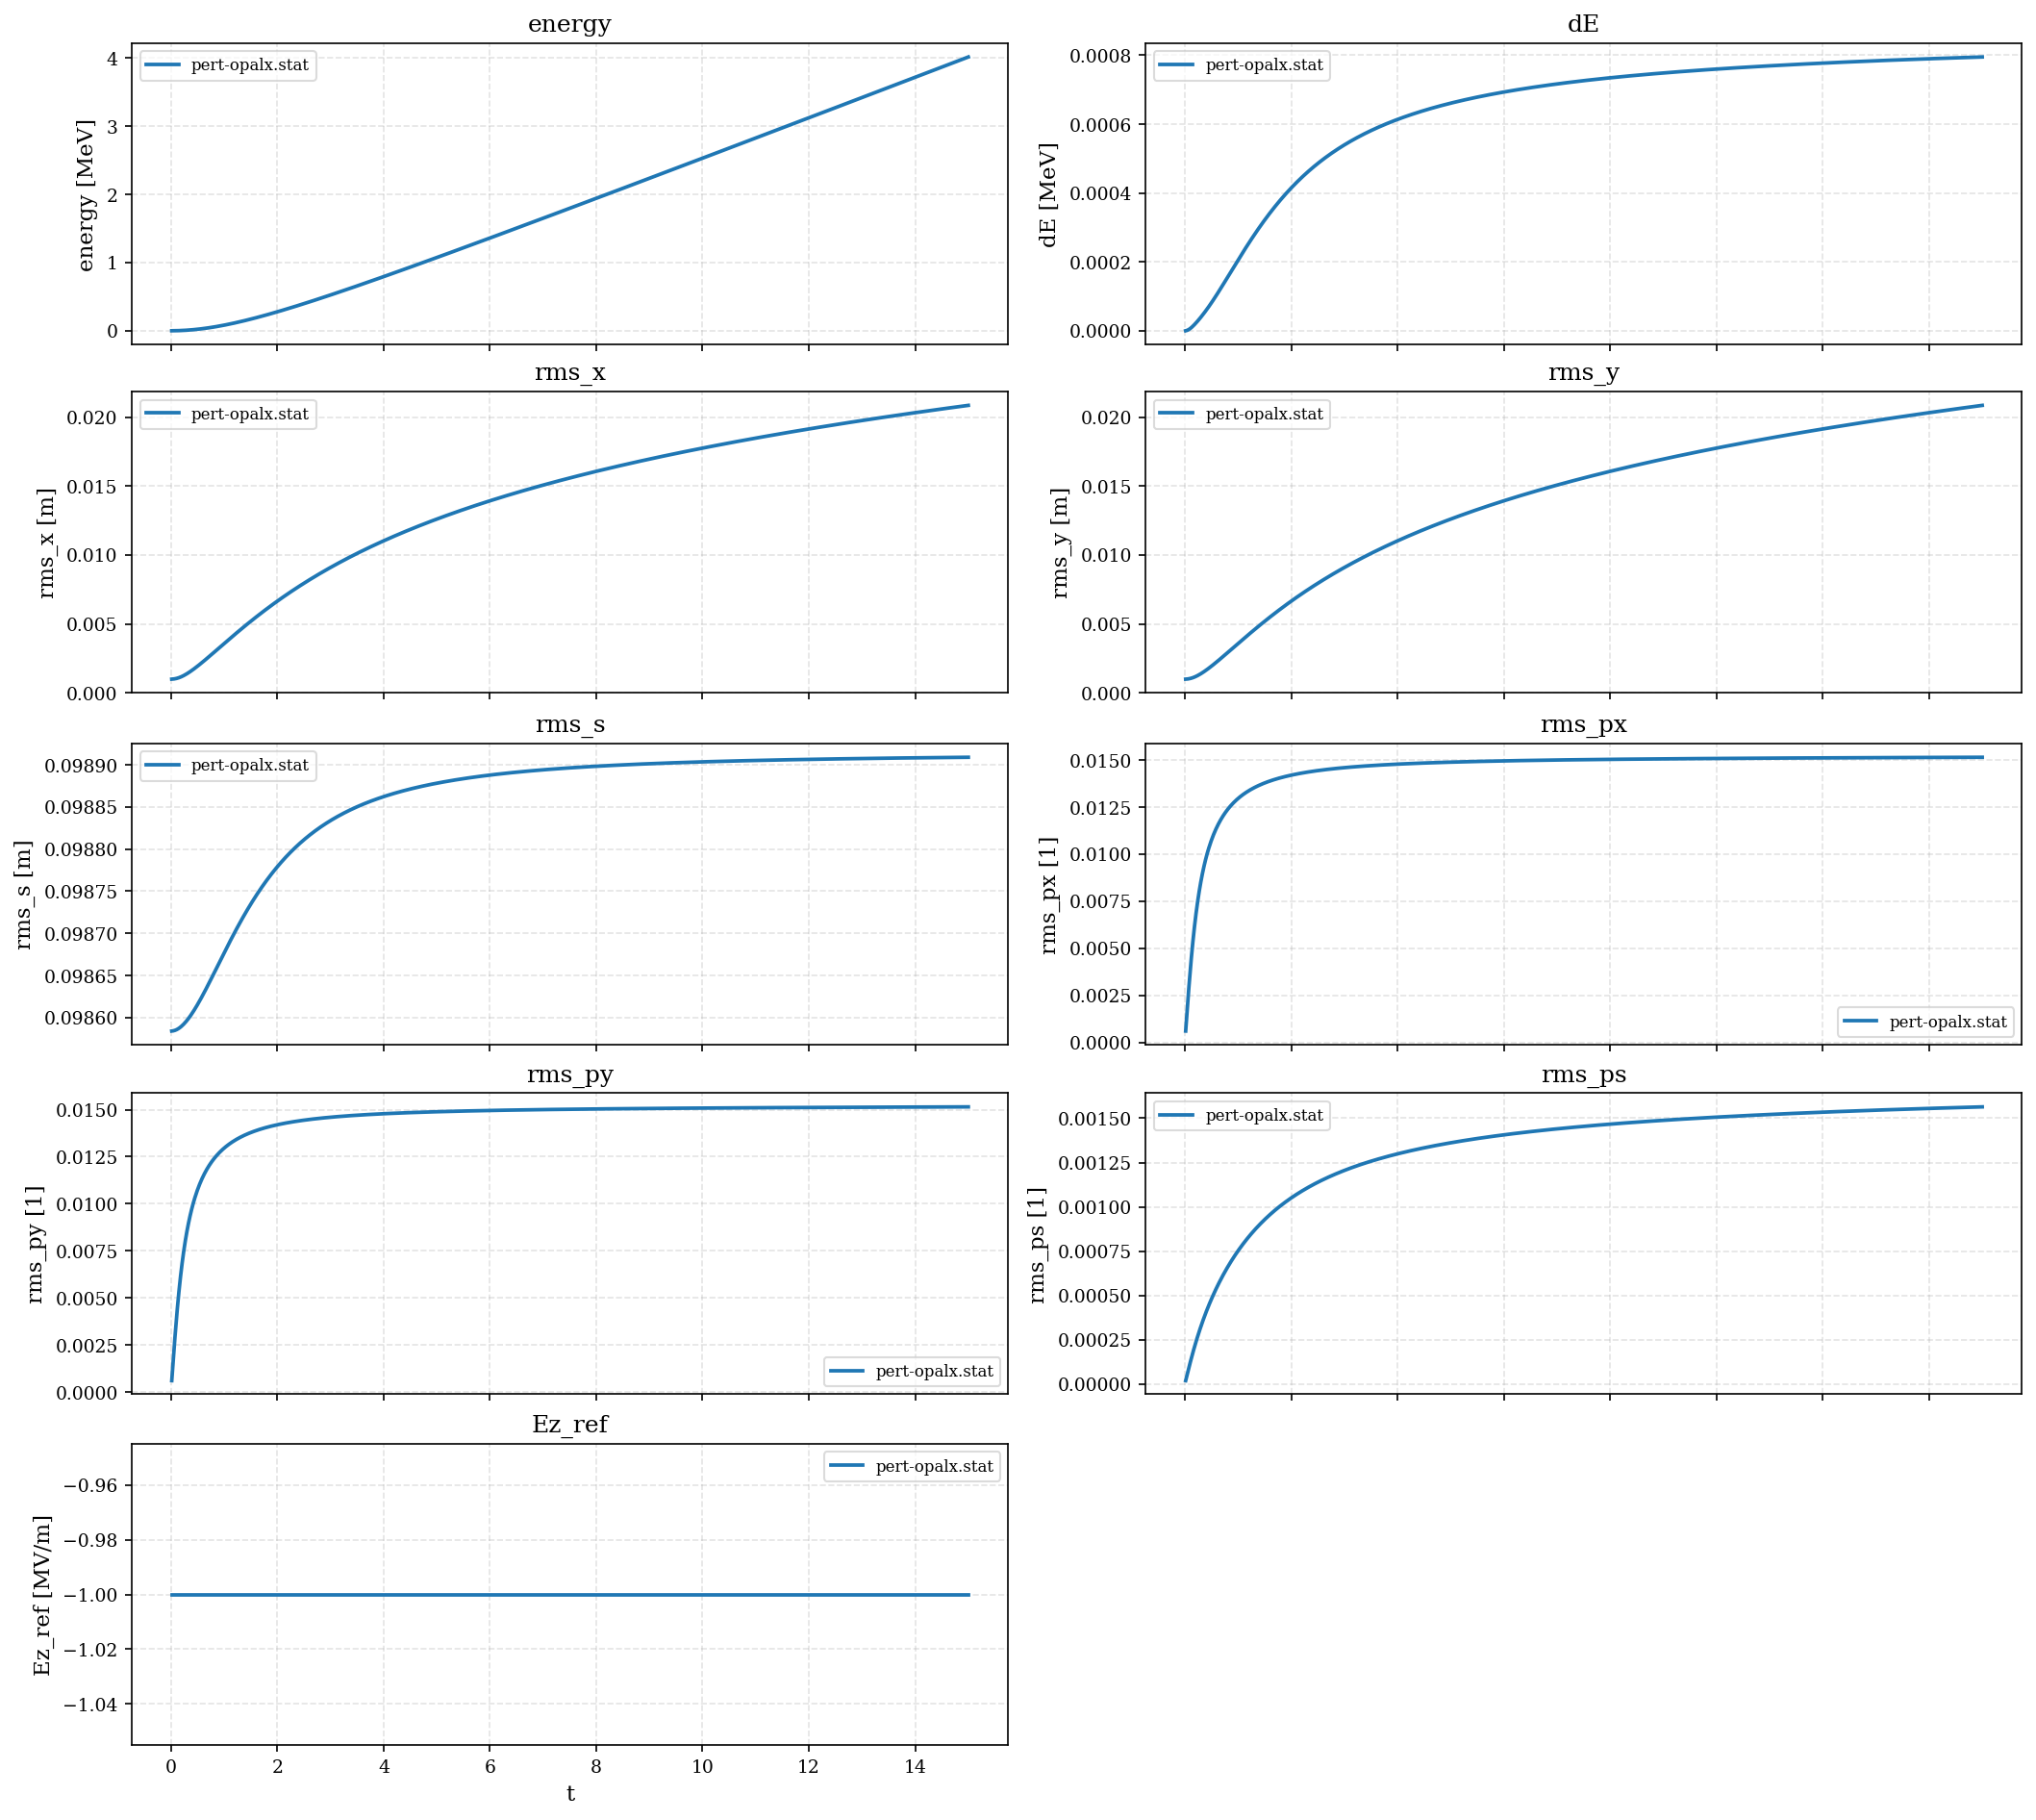

In [2]:
columns = [
    "energy",
    "dE",
    "rms_x",
    "rms_y",
    "rms_s",
    "rms_px",
    "rms_py",
    "rms_ps",
    "Ez_ref",
]

compare_stats(
    "opalx-sim/pert-opalx.stat",
    columns=columns,
    #data_range=[0, 200],  # e.g. [0, 200]
    save_as="comparison.png",
    x_col="t",
)


In [3]:
def load_lw_moments(moments_path="output/moments.csv", trajectories_path=None):
    """Load Python LW moments and add a dE column when trajectories are available."""
    moments_path = os.fspath(moments_path)
    moments = pd.read_csv(moments_path)
    lw = pd.DataFrame({
        "t": moments["time_s"] * 1.0e9,  # OPALX .stat time is ns
        "rms_x": moments["rms_x_m"],
        "rms_y": moments["rms_y_m"],
        "rms_s": moments["rms_z_m"],
        "rms_px": moments["rms_px_beta_gamma"],
        "rms_py": moments["rms_py_beta_gamma"],
        "rms_ps": moments["rms_pz_beta_gamma"],
        "energy": moments["mean_kinetic_energy_MeV"],
    })

    if trajectories_path is None:
        trajectories_path = os.path.join(os.path.dirname(moments_path), "trajectories.npz")

    if trajectories_path and os.path.exists(trajectories_path):
        traj = np.load(trajectories_path)
        lw["dE"] = np.std(traj["kinetic_energy_MeV"], axis=1)
    else:
        print("No trajectories.npz found; skipping Python energy-spread comparison.")

    return lw


def compare_opalx_to_lw_moments(
    stat_path="opalx-sim/pert-opalx.stat",
    moments_path="output/moments.csv",
    trajectories_path=None,
    columns=None,
    data_range=None,
    save_as="opalx_vs_lw_moments.png",
    ncols=2,
):
    """Compare OPALX .stat output against Python LW moments.

    OPALX columns are compared to Python columns with the same normalized names:
    rms_x/rms_y/rms_s [m], rms_px/rms_py/rms_ps [beta*gamma], energy [MeV],
    and dE [MeV] when trajectories.npz is available.
    """
    if columns is None:
        columns = [
            "rms_x",
            "rms_y",
            "rms_s",
            "rms_px",
            "rms_py",
            "rms_ps",
            "energy",
            "dE",
        ]
    columns = list(columns)

    opalx, col_info = read_sdds_file(stat_path)
    lw = load_lw_moments(moments_path, trajectories_path=trajectories_path)

    missing_opalx = [col for col in columns if col not in opalx.columns]
    missing_lw = [col for col in columns if col not in lw.columns]
    if missing_opalx:
        raise ValueError(f"Missing OPALX columns: {missing_opalx}")
    if missing_lw:
        print(f"Skipping columns missing in Python LW moments: {missing_lw}")
        columns = [col for col in columns if col in lw.columns]
    if not columns:
        raise ValueError("No comparable columns remain")

    if data_range is None:
        row_slice = slice(None)
    else:
        start, stop = data_range
        row_slice = slice(start, stop)

    opalx_view = opalx.iloc[row_slice].copy()
    opalx_t = opalx_view["t"].to_numpy()
    lw_t = lw["t"].to_numpy()

    valid_time = (opalx_t >= lw_t.min()) & (opalx_t <= lw_t.max())
    if not np.any(valid_time):
        raise ValueError("OPALX and Python LW time grids do not overlap")
    opalx_view = opalx_view.loc[valid_time].copy()
    opalx_t = opalx_view["t"].to_numpy()

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 8,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.dpi": 150,
        "savefig.dpi": 200,
        "axes.grid": True,
        "grid.alpha": 0.35,
        "grid.linestyle": "--",
    })

    labels = {
        "rms_x": "RMS x [m]",
        "rms_y": "RMS y [m]",
        "rms_s": "RMS z/s [m]",
        "rms_px": "RMS px [beta*gamma]",
        "rms_py": "RMS py [beta*gamma]",
        "rms_ps": "RMS pz/ps [beta*gamma]",
        "energy": "mean kinetic energy [MeV]",
        "dE": "energy spread [MeV]",
    }

    ncols = max(1, min(int(ncols), len(columns)))
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7 * ncols, 2.6 * nrows),
        sharex=True,
        constrained_layout=True,
        squeeze=False,
    )

    for ax, col in zip(axes.ravel(), columns):
        opalx_y = opalx_view[col].to_numpy()
        lw_y = np.interp(opalx_t, lw_t, lw[col].to_numpy())
        abs_err = np.abs(opalx_y - lw_y)

        ax.plot(opalx_t, opalx_y, label="OPALX .stat", lw=1.8)
        ax.plot(opalx_t, lw_y, label="Python LW", lw=1.8)
        ax.set_title(col)
        ax.set_ylabel(labels.get(col, col))
        ax.legend(loc="best", framealpha=0.7)

        ax_err = ax.twinx()
        ax_err.plot(opalx_t, abs_err, color="silver", lw=1.2, ls="--", alpha=0.8, label="|Delta|")
        ax_err.set_ylabel("|Delta|", color="silver", fontsize=9)
        ax_err.tick_params(axis="y", colors="silver", labelsize=8)
        ax_err.yaxis.get_offset_text().set_color("silver")
        if np.any(abs_err > 0):
            ax_err.set_yscale("log")

    for ax in axes.ravel()[len(columns):]:
        ax.set_visible(False)
    for ax in axes[-1, :]:
        if ax.get_visible():
            ax.set_xlabel("t [ns]")

    if save_as is not None:
        plt.savefig(save_as)
    plt.show()

    summary_rows = []
    for col in columns:
        opalx_y = opalx_view[col].to_numpy()
        lw_y = np.interp(opalx_t, lw_t, lw[col].to_numpy())
        abs_err = np.abs(opalx_y - lw_y)
        denom = np.maximum(np.abs(lw_y), 1e-30)
        summary_rows.append({
            "column": col,
            "max_abs_error": np.max(abs_err),
            "mean_abs_error": np.mean(abs_err),
            "max_relative_error": np.max(abs_err / denom),
            "mean_relative_error": np.mean(abs_err / denom),
        })
    return pd.DataFrame(summary_rows)


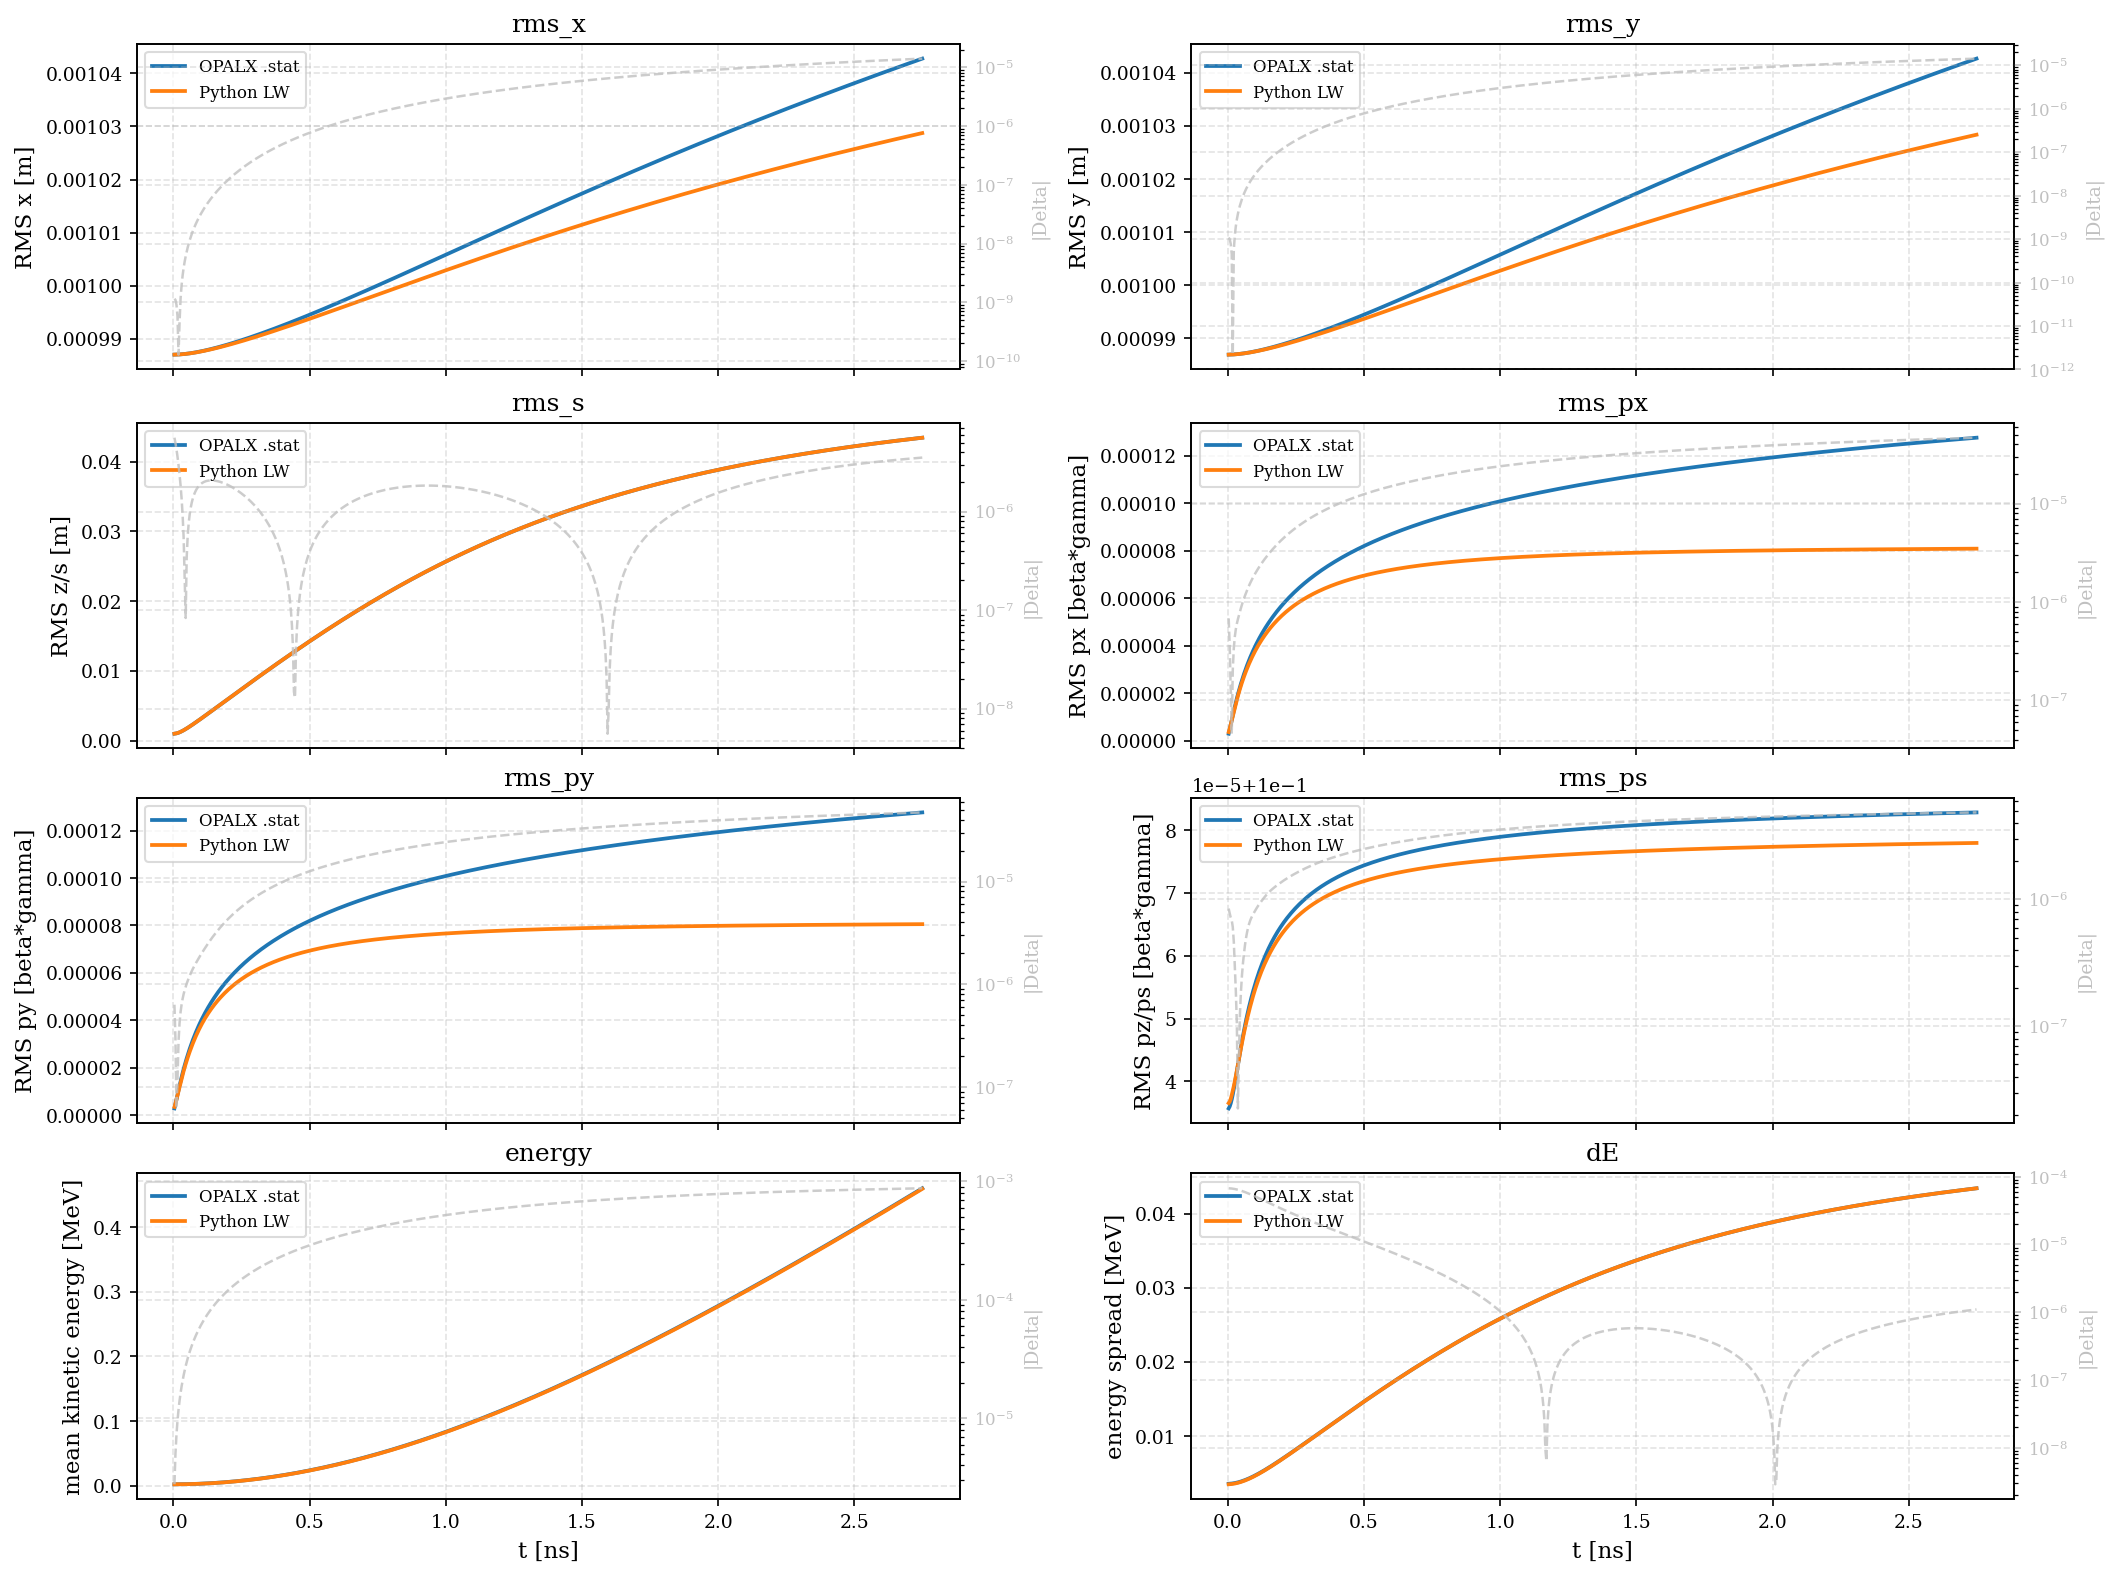

,column,max_abs_error,mean_abs_error,max_relative_error,mean_relative_error
0,rms_x,0.000014,0.000006,0.013624,0.005583
1,rms_y,0.000014,0.000006,0.013933,0.005722
2,rms_s,0.000006,0.000002,0.005625,0.000114
3,rms_px,0.000047,0.000028,0.578304,0.358128
4,rms_py,0.000047,0.000028,0.584672,0.362542
5,rms_ps,0.000005,0.000004,0.000049,0.000036
6,energy,0.000876,0.000574,0.020289,0.006560
7,dE,0.000067,0.000007,0.019234,0.001118


In [30]:
comparison_summary = compare_opalx_to_lw_moments(
    # stat_path="opalx-sim/pert-opalx.stat",
    # stat_path="opalx-sim/gh200-256-1E8.stat",
    # stat_path="opalx-sim/pert-test-no-mom.stat",
    stat_path="opalx-sim/pert-test-no-bins.stat",
    moments_path="output/moments.csv",
    trajectories_path="output/trajectories.npz",
    save_as="comparison.png",
    #data_range=[0, 50],
)
comparison_summary


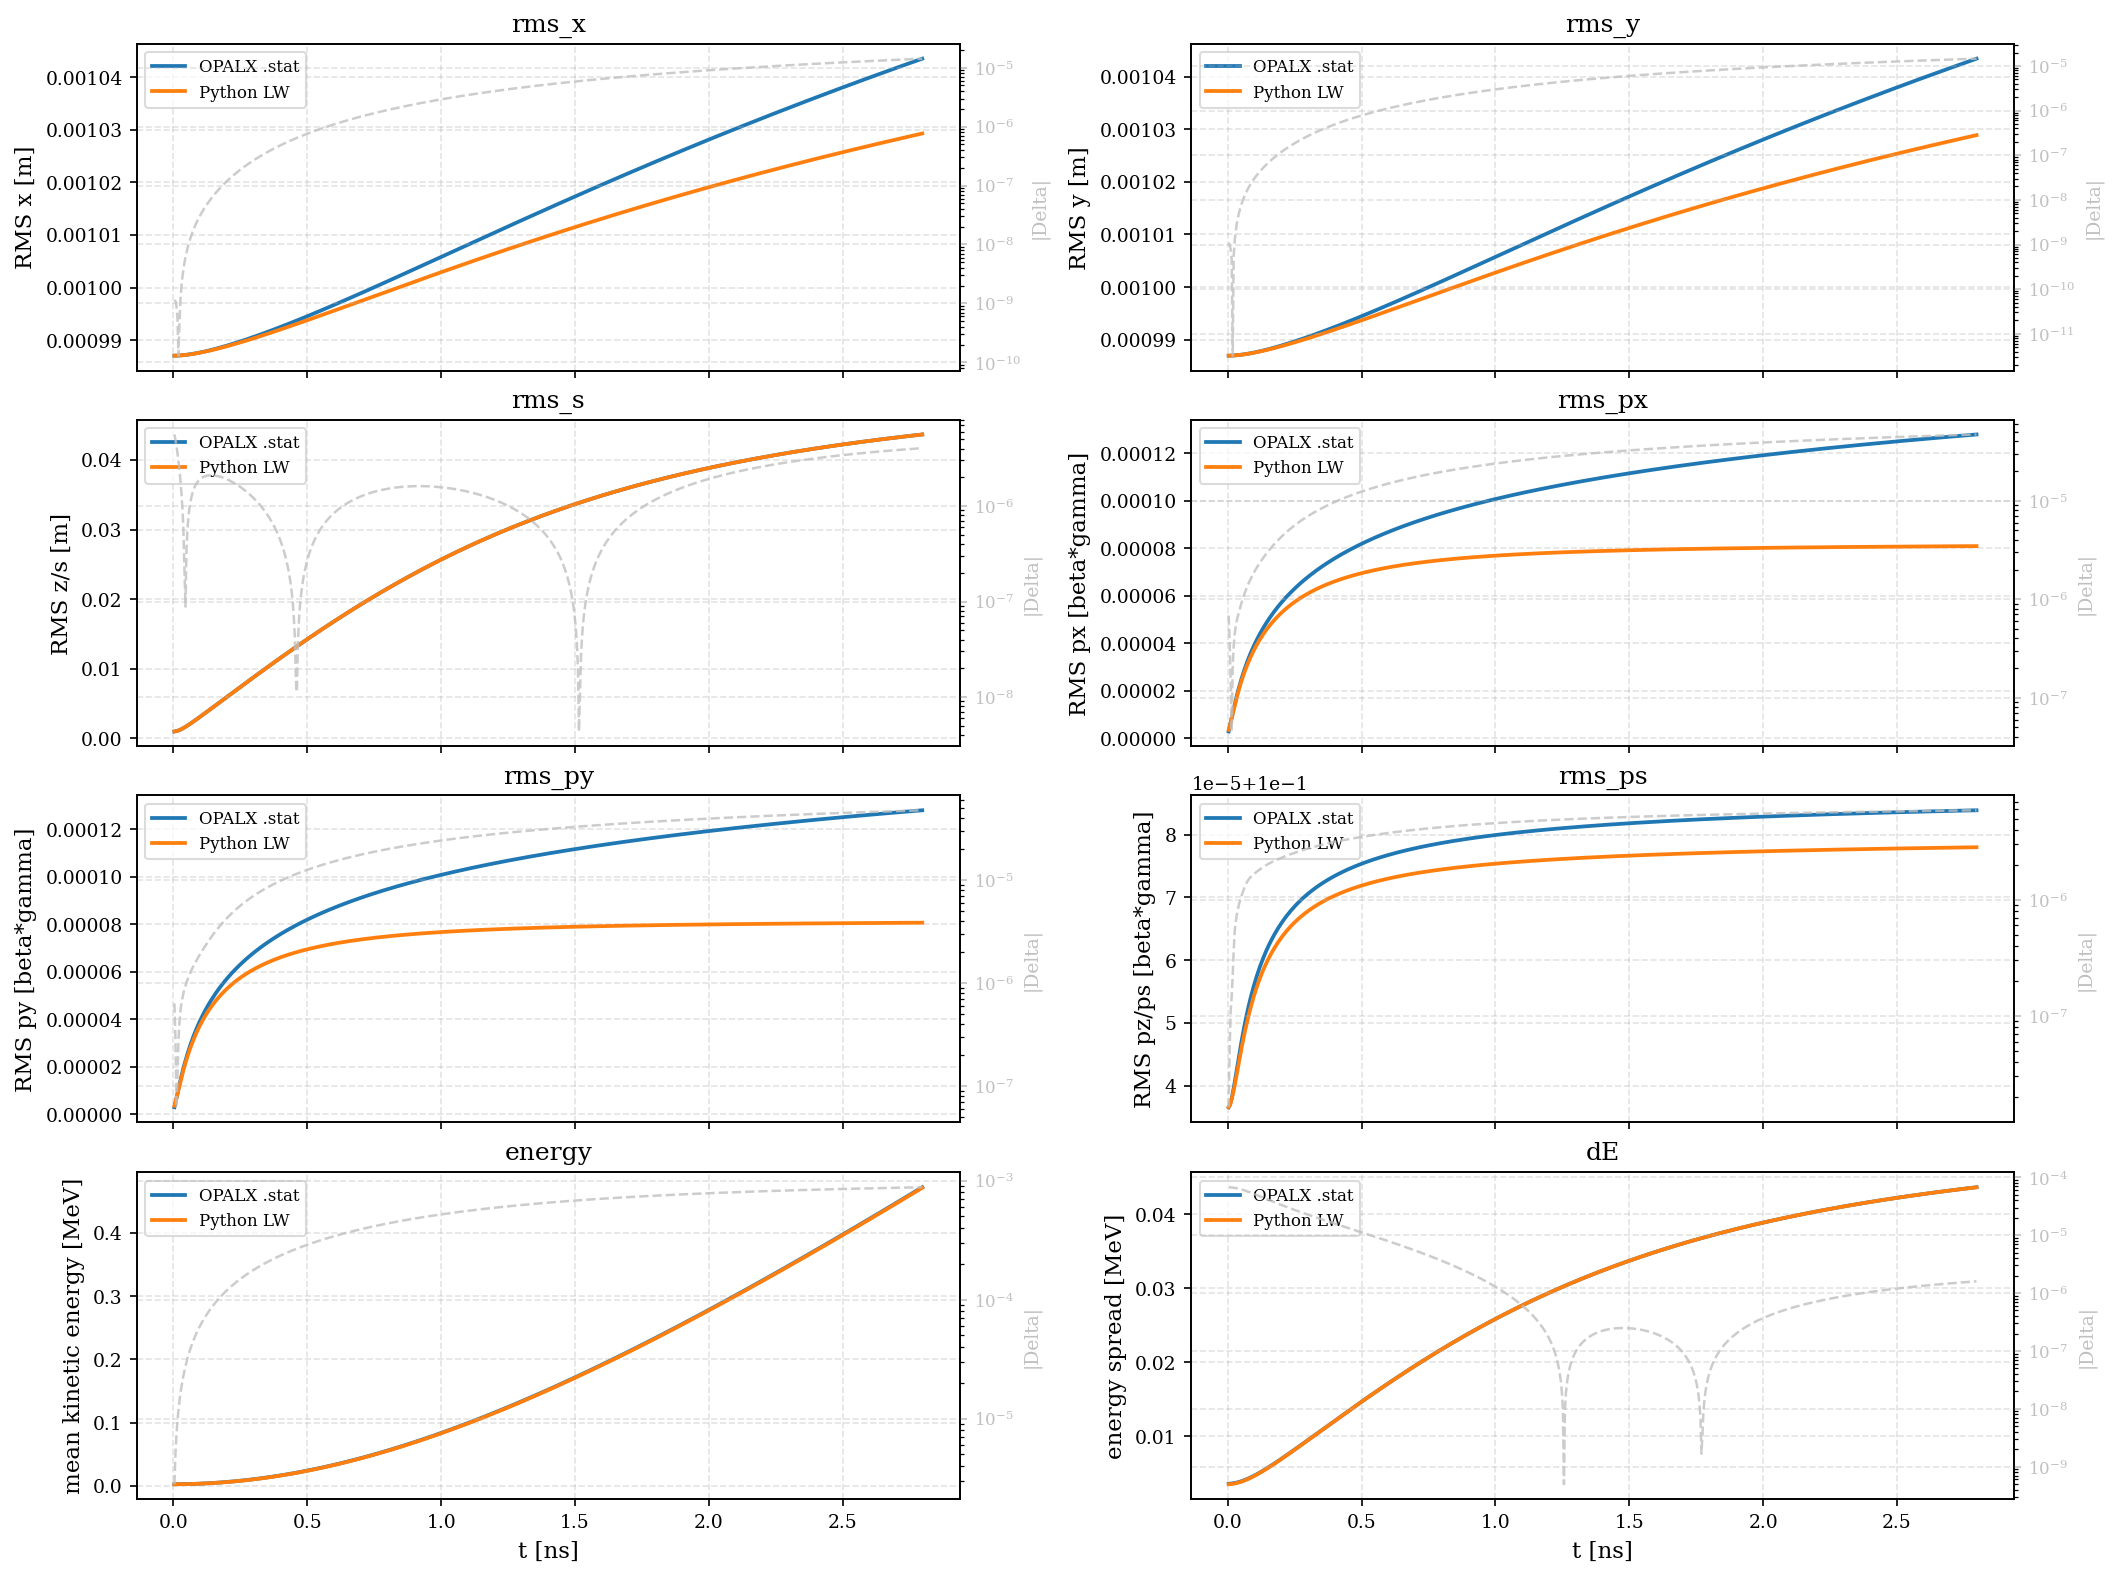

,column,max_abs_error,mean_abs_error,max_relative_error,mean_relative_error
0,rms_x,0.000014,0.000006,0.013830,0.005684
1,rms_y,0.000015,0.000006,0.014144,0.005825
2,rms_s,0.000006,0.000002,0.005625,0.000116
3,rms_px,0.000047,0.000028,0.580746,0.360059
4,rms_py,0.000047,0.000028,0.587125,0.364501
5,rms_ps,0.000006,0.000005,0.000059,0.000046
6,energy,0.000880,0.000579,0.020295,0.006480
7,dE,0.000067,0.000007,0.019252,0.001105


In [ ]:
comparison_summary = compare_opalx_to_lw_moments(
    # stat_path="opalx-sim/pert-opalx.stat",
    # stat_path="opalx-sim/gh200-256-1E8.stat",
    # stat_path="opalx-sim/pert-test-no-mom.stat",
    stat_path="opalx-sim/pert-test-binned.stat",
    moments_path="output/moments.csv",
    trajectories_path="output/trajectories.npz",
    save_as="comparison.png",
    #data_range=[0, 50],
)
comparison_summary


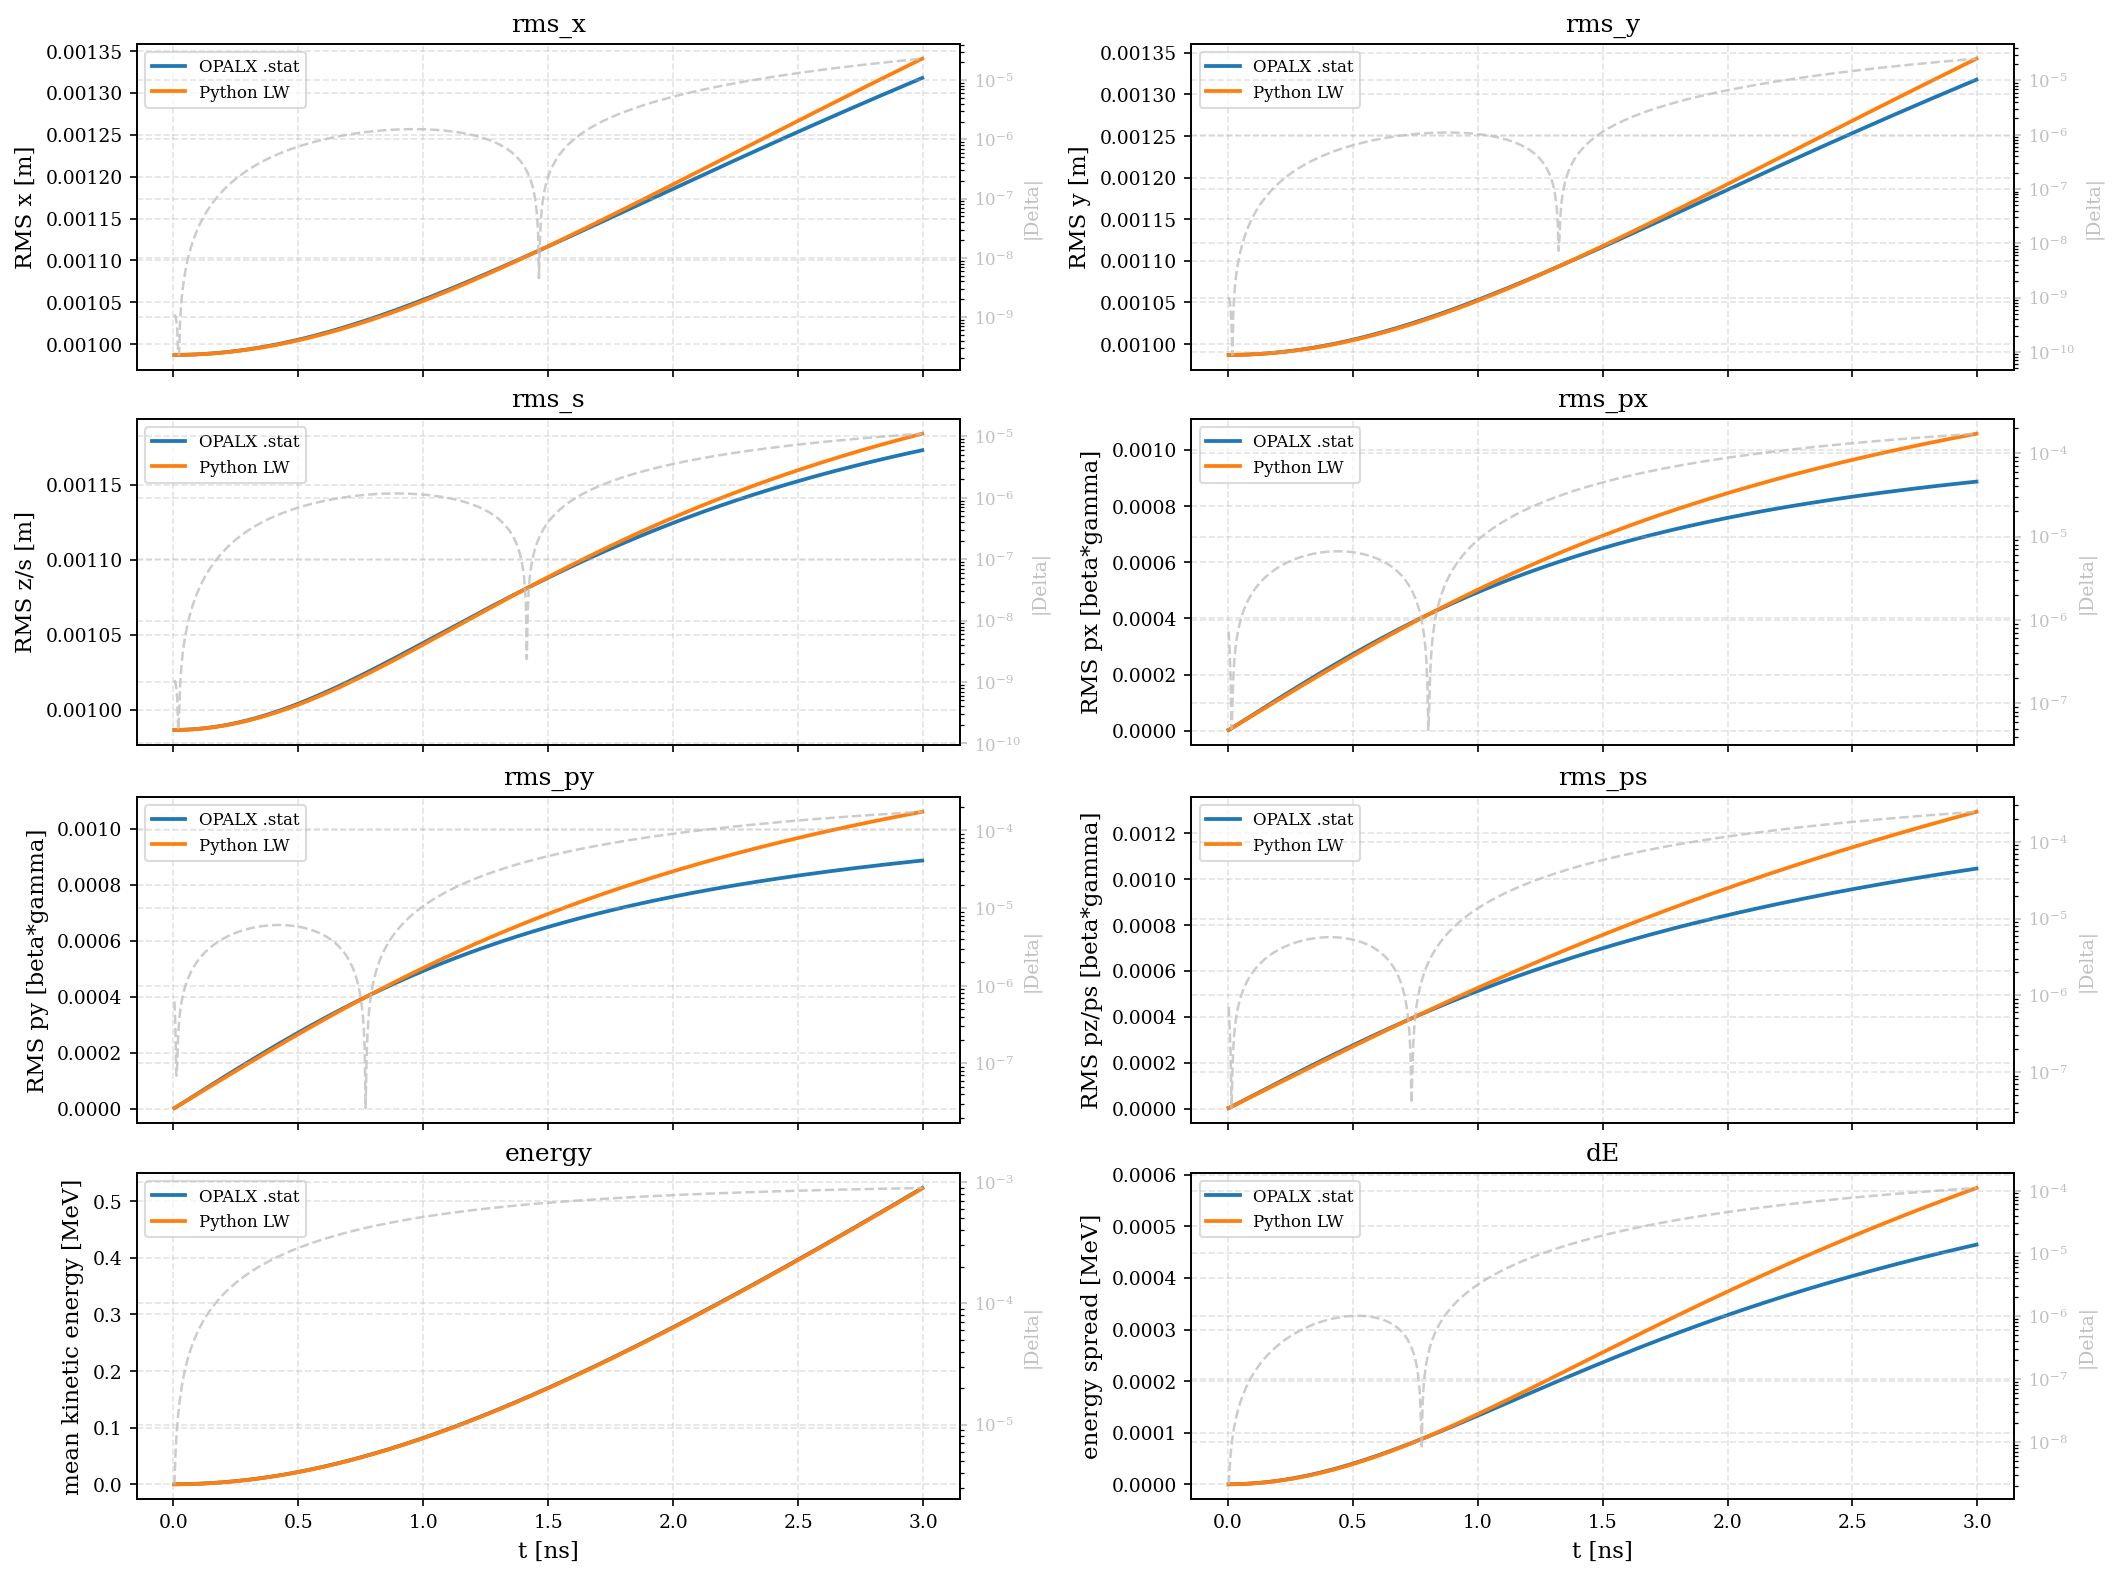

,column,max_abs_error,mean_abs_error,max_relative_error,mean_relative_error
0,rms_x,0.000023,0.000005,0.017214,0.004252
1,rms_y,0.000025,0.000006,0.018791,0.004771
2,rms_s,0.000011,0.000003,0.009307,0.002680
3,rms_px,0.000171,0.000060,0.200947,0.073710
4,rms_py,0.000174,0.000062,0.178365,0.075436
5,rms_ps,0.000248,0.000083,0.196208,0.085633
6,energy,0.000892,0.000595,2.607113,0.017571
7,dE,0.000110,0.000033,0.526507,0.090411


In [ ]:
"""
This run was performed with a uniform 1e-3 sphere and rms_pX = 1e-6. Command used to run it:
uv run python python/lw_perturbation/run_lw_test.py \
  --particles 512 \
  --t-end 3e-9 \
  --outputs 801 \
  --smoothing-grid-cells 64 \
  --smoothing-extent-sigmas 3.0 \
  --workers 8 --match-initial-stat python/lw_perturbation/opalx-sim/pert-test-uniformsphere.stat

Corresponding OPALX input file is under `pert-opalx.in` and was run with 8 GH200 ranks. 
I think this pretty much shows that the first order approximation works well. However,
in order to use a wider momentum spread, we would need much higher resolution in OPALX 
or alternatively a e.g. second order model in Python?
"""

comparison_summary = compare_opalx_to_lw_moments(
    # stat_path="opalx-sim/pert-opalx.stat",
    # stat_path="opalx-sim/gh200-256-1E8.stat",
    # stat_path="opalx-sim/pert-test-no-mom.stat",
    stat_path="opalx-sim/pert-test-uniformsphere.stat",
    moments_path="output/moments.csv",
    trajectories_path="output/trajectories.npz",
    save_as="comparison.png",
    #data_range=[0, 50],
)
comparison_summary
